# DCGAN for cat images

## Imports

In [6]:
import time
import sys
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.append(os.path.abspath('..'))

from scripts import (
    DataFixedConfig,
    DataGridConfig,
    GANExperiment,
    GANFixedConfig,
    GANGridConfig,
    TrainFixedConfig,
    TrainGridConfig,
    build_dataloaders,
    build_gan,
    compute_fid,
    count_parameters,
    expand_experiment_grid,
    gan_sample_iterator,
    interpolate_gan,
    output_paths,
    prepare_data,
    report_fid,
    run_name,
    sample_gan_latents,
    save_history,
    save_history_plot,
    save_interpolation_grid,
    save_json,
    save_sample_grid,
    train_gan,
    update_total_stats,
)

## Parameters

In [7]:
# Tier 1/2 FID-targeting recipe for this notebook:
#   - RGB (no grayscale/posterize) so the InceptionV3 feature space is used as designed
#   - TTUR: LR_D > LR_G to keep the discriminator informative
#   - AMP (mixed precision) + larger batch -> ~1.7x throughput on T4
#   - EMA on the generator -> typically -10 to -20% FID
#   - RandomResizedCrop + ColorJitter -> larger effective dataset for ~10k cats
#   - FID 5k/5k for stable scores instead of 1k/1k

EXPERIMENT_NAME = "gan"

# --- Data ---------------------------------------------------------------
DATA_DIR = "../data/cats"
OUTPUT_DIR = "../reports/runs"
CACHE_DIR = "../.cache/fid"
IMAGE_SIZE = 64
TRAIN_FRACTION = 0.95
VALIDATION_FRACTION = 0.05
AUGMENT_FLIP = True
GRAYSCALE = False
POSTERIZE_BITS = 6
RESIZED_CROP_SCALE = (0.85, 1.0)   # mild RandomResizedCrop; None disables
# RESIZED_CROP_SCALE = None   # mild RandomResizedCrop; None disables
COLOR_JITTER = (0.1, 0.1, 0.1)     # (brightness, contrast, saturation); None disables
# COLOR_JITTER = None     # (brightness, contrast, saturation); None disables
NUM_WORKERS = 4
PIN_MEMORY = True

# --- Generator / Discriminator -----------------------------------------
LATENT_DIM = 128
GENERATOR_FEATURES = 64
DISCRIMINATOR_FEATURES = 64
SPECTRAL_NORM = True
LABEL_SMOOTHING = 0.1
N_DISC_STEPS = 1

# --- Optimization -------------------------------------------------------
# TTUR (Heusel et al.): faster discriminator stabilizes adversarial dynamics.
LEARNING_RATE_G = 2e-4
LEARNING_RATE_D = 4e-4
ADAM_BETA1 = 0.5
ADAM_BETA2 = 0.999
# EPOCHS = 150
EPOCHS = 200
BATCH_SIZE = 128
SEED = 42

# --- AMP / EMA / LR schedule -------------------------------------------
AMP = True                 # mixed precision on CUDA; falls back silently on CPU
EMA_DECAY = 0.999          # 0 disables; EMA generator is used for sampling/FID
LR_WARMUP_STEPS = 1      # linear warmup over the first 500 generator steps
LR_COSINE_DECAY = True     # cosine-anneal LRs over the full training schedule

# --- Mode collapse heuristic -------------------------------------------
MODE_COLLAPSE_WINDOW = 50
MODE_COLLAPSE_MIN_STD = 1e-3

# --- Checkpointing ------------------------------------------------------
SAVE_CHECKPOINT = True
RESUME_FROM = None

# --- Logging / sampling -------------------------------------------------
SAMPLE_EVERY = 10
FID_REAL_SAMPLES = 5000
FID_FAKE_SAMPLES = 5000
DEVICE = "cuda"
PROGRESS_BACKEND = "terminal"

experiment = GANExperiment(
    name=EXPERIMENT_NAME,
    data_fixed=DataFixedConfig(
        data_dir=DATA_DIR,
        cache_dir=CACHE_DIR,
        output_dir=OUTPUT_DIR,
        image_size=IMAGE_SIZE,
        channels=1 if GRAYSCALE else 3,
        grayscale=GRAYSCALE,
        posterize_bits=POSTERIZE_BITS,
        resized_crop_scale=RESIZED_CROP_SCALE,
        color_jitter=COLOR_JITTER,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    ),
    data_grid=DataGridConfig(
        train_fraction=TRAIN_FRACTION,
        validation_fraction=VALIDATION_FRACTION,
        augment_flip=AUGMENT_FLIP,
        seed=SEED,
    ),
    train_fixed=TrainFixedConfig(
        device=DEVICE,
        progress_backend=PROGRESS_BACKEND,
        fid_real_samples=FID_REAL_SAMPLES,
        fid_fake_samples=FID_FAKE_SAMPLES,
    ),
    train_grid=TrainGridConfig(
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        sample_every=SAMPLE_EVERY,
    ),
    model_fixed=GANFixedConfig(
        spectral_norm=SPECTRAL_NORM,
        mode_collapse_window=MODE_COLLAPSE_WINDOW,
        mode_collapse_min_std=MODE_COLLAPSE_MIN_STD,
        amp=AMP,
        ema_decay=EMA_DECAY,
        lr_warmup_steps=LR_WARMUP_STEPS,
        lr_cosine_decay=LR_COSINE_DECAY,
    ),
    model_grid=GANGridConfig(
        latent_dim=LATENT_DIM,
        generator_features=GENERATOR_FEATURES,
        discriminator_features=DISCRIMINATOR_FEATURES,
        learning_rate_g=LEARNING_RATE_G,
        learning_rate_d=LEARNING_RATE_D,
        label_smoothing=LABEL_SMOOTHING,
        n_disc_steps=N_DISC_STEPS,
        beta1=ADAM_BETA1,
        beta2=ADAM_BETA2,
    ),
)

runs = expand_experiment_grid(experiment)
run = runs[0]
print(f"Generated {len(runs)} configuration(s); the first is selected for this notebook run.")


Generated 1 configuration(s); the first is selected for this notebook run.


## Setup

In [8]:
torch.manual_seed(run["data"]["seed"])
np.random.seed(run["data"]["seed"])

run_dir = run_name(experiment.kind, run)
paths = output_paths(experiment.name, experiment.data_fixed.output_dir, run_dir)
save_json(paths["configs"] / "run.json", {"experiment": experiment.name, **run})
print(f"Run output: {paths['root']}")

prepared = prepare_data(
    experiment.data_fixed,
    train_fraction=run["data"]["train_fraction"],
    validation_fraction=run["data"]["validation_fraction"],
    augment_flip=run["data"]["augment_flip"],
    seed=run["data"]["seed"],
)
print(f"Train images: {len(prepared.train_dataset)} | Validation: {len(prepared.validation_dataset)}")

train_loader, _ = build_dataloaders(
    prepared,
    experiment.data_fixed,
    batch_size=run["train"]["batch_size"],
    seed=run["data"]["seed"],
)

generator, discriminator = build_gan(run["model"], experiment.model_fixed, experiment.data_fixed)
print(
    f"Generator parameters: {count_parameters(generator):,} | "
    f"Discriminator parameters: {count_parameters(discriminator):,}"
)


Run output: ..\reports\runs\gan\20260615_003303_gan_z128_g64_d64_lr0_0002_ls0_1_e200
Train images: 29919 | Validation: 1575
Generator parameters: 3,806,080 | Discriminator parameters: 2,763,776


## Training

In [9]:
training_result = train_gan(
    generator,
    discriminator,
    train_loader,
    model_params=run["model"],
    train_params=run["train"],
    train_fixed=experiment.train_fixed,
    fixed_params=experiment.model_fixed,
    sample_dir=paths["samples"],
    checkpoint_path=paths["checkpoints"] / "gan_final.pt" if SAVE_CHECKPOINT else None,
    resume_from=RESUME_FROM,
)

history = training_result["history"]
collapse_events = training_result["mode_collapse_events"]
save_history(history, paths["metrics"] / "history.csv")
save_history_plot(
    history,
    paths["figures"] / "loss_curves.png",
    metrics=["d_loss", "g_loss", "real_logit", "fake_logit"],
    title="GAN Loss Curves",
)
save_json(paths["metrics"] / "mode_collapse.json", {"events": collapse_events})
elapsed = training_result["elapsed_seconds"]
print(
    f"Trained in {int(elapsed // 3600):02d}:{int(elapsed % 3600 // 60):02d}:{int(elapsed % 60):02d} on {training_result['device']}; "
    f"mode-collapse warnings: {len(collapse_events)}."
)
update_total_stats(
    experiment.data_fixed.output_dir,
    experiment.kind,
    run_dir,
    experiment.name,
    elapsed,
    training_result["device"],
)

Using device: cuda
Generator parameters: 3,806,080; Discriminator parameters: 2,763,776


GAN Training: 100%|██████████| 200/200 [2:38:10<00:00, 47.45s/it, d=1.350, fl=0.00, g=0.693, rl=0.10]   

Copied EMA weights into generator for evaluation.


Saved GAN checkpoint to ..\reports\runs\gan\20260615_003303_gan_z128_g64_d64_lr0_0002_ls0_1_e200\checkpoints\gan_final.pt.
GAN training finished in 02:38:11
Trained in 02:38:11 on cuda; mode-collapse warnings: 0.


## Evaluation

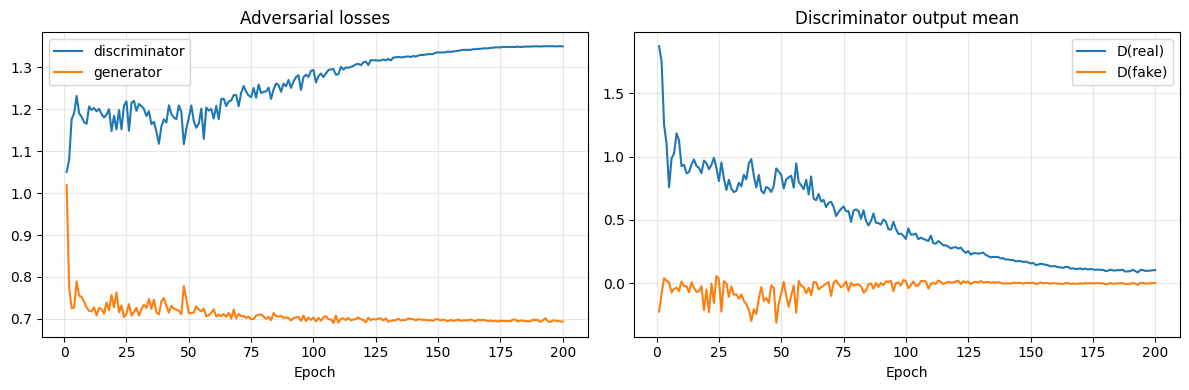

Generated → Inception: 40it [00:13,  2.98it/s]


FID: 26.604 (sampling took 00:00:27)


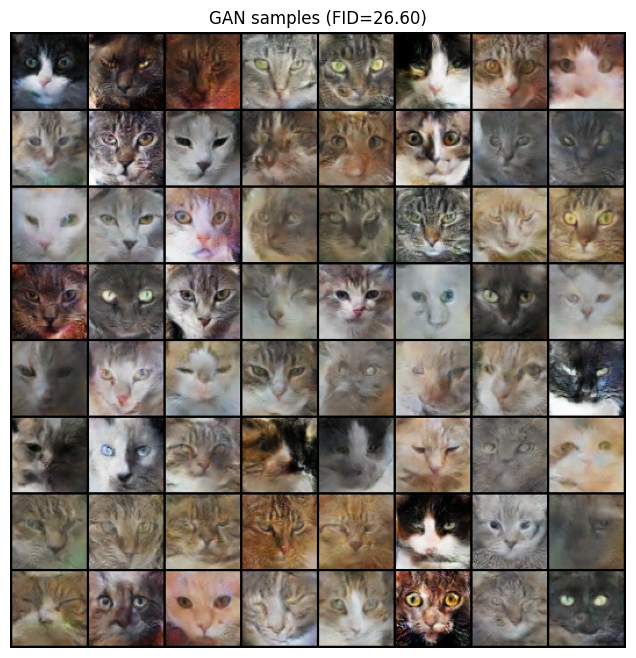

In [10]:
device = next(generator.parameters()).device

with torch.no_grad():
    noise = torch.randn(64, generator.latent_dim, 1, 1, device=device)
    save_sample_grid(generator(noise), paths["figures"] / "samples_final.png", nrow=8)

metrics_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(metrics_df["epoch"], metrics_df["d_loss"], label="discriminator")
axes[0].plot(metrics_df["epoch"], metrics_df["g_loss"], label="generator")
axes[0].set_title("Adversarial losses")
axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(metrics_df["epoch"], metrics_df["real_logit"], label="D(real)")
axes[1].plot(metrics_df["epoch"], metrics_df["fake_logit"], label="D(fake)")
axes[1].set_title("Discriminator output mean")
axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

sampler = gan_sample_iterator(
    generator,
    num_samples=experiment.train_fixed.fid_fake_samples,
    batch_size=run["train"]["batch_size"],
    device=device,
    seed=run["data"]["seed"],
)
fid_start = time.perf_counter()
fid_score = compute_fid(
    sampler,
    experiment.data_fixed,
    num_real_samples=experiment.train_fixed.fid_real_samples,
    seed=run["data"]["seed"],
    device=device,
)
fid_elapsed = time.perf_counter() - fid_start
report_fid(fid_score, elapsed_seconds=fid_elapsed)
save_json(paths["metrics"] / "fid.json", {"fid": fid_score, "elapsed_seconds": fid_elapsed})

img = plt.imread(paths["figures"] / "samples_final.png")
plt.figure(figsize=(8, 8))
plt.imshow(img); plt.axis("off")
plt.title(f"GAN samples (FID={fid_score:.2f})")
plt.show()


## Interpolation

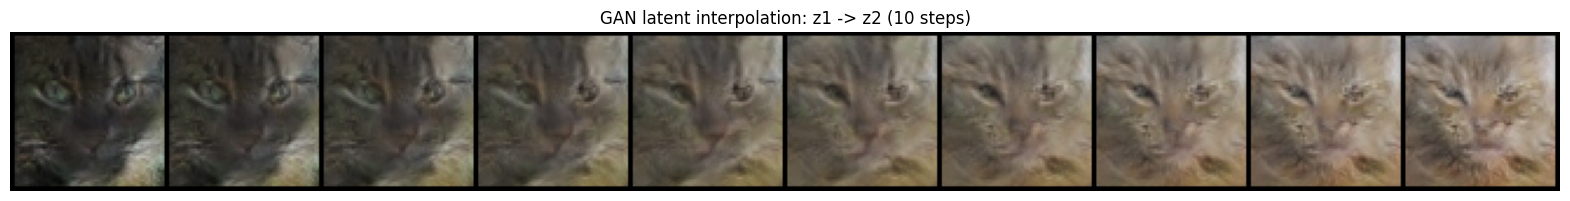

In [11]:
z1, z2 = sample_gan_latents(generator, device, run["data"]["seed"])
images = interpolate_gan(generator, z1, z2, num_steps=10)
interpolation_path = paths["figures"] / "interpolation.png"
save_interpolation_grid(images, interpolation_path)

img = plt.imread(interpolation_path)
plt.figure(figsize=(20, 2.6))
plt.imshow(img); plt.axis("off")
plt.title("GAN latent interpolation: z1 -> z2 (10 steps)")
plt.show()
